# 02 — Exploratory Data Analysis

**Goal of this notebook**: understand what we're working with before building anything —
class balance, how slices distribute across patients, visual sample inspection, and
whether the Br35H "no tumor" images look consistent with the Figshare tumor slices
(different acquisition sources can introduce a subtle shortcut-learning risk if the
model learns to tell datasets apart rather than tumor presence).

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metadata = pd.read_csv("../data/processed/metadata.csv")
metadata.head()

,image_path,label,patient_id,source_dataset
0,..\data\raw\figshare_mat\1.mat,meningioma,figshare_100360,figshare
1,..\data\raw\figshare_mat\10.mat,meningioma,figshare_101016,figshare
2,..\data\raw\figshare_mat\100.mat,meningioma,figshare_107494,figshare
3,..\data\raw\figshare_mat\1000.mat,pituitary,figshare_112649,figshare
4,..\data\raw\figshare_mat\1001.mat,pituitary,figshare_112649,figshare


## Class balance

**Intent**: check how imbalanced the 4 classes are — this determines whether we need
class weighting or stronger augmentation for minority classes during training.

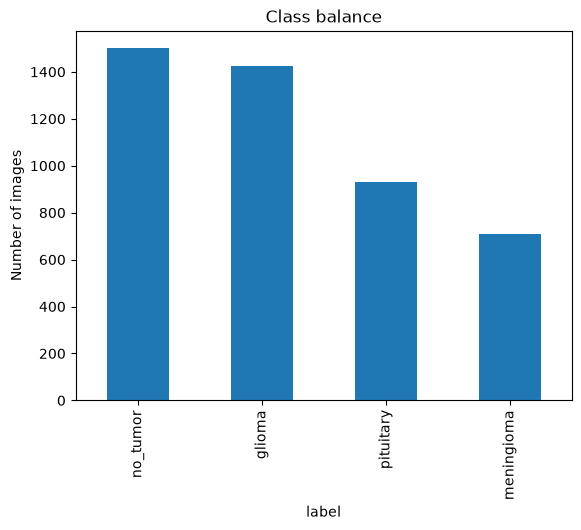

label
no_tumor      1500
glioma        1426
pituitary      930
meningioma     708
Name: count, dtype: int64


In [2]:
class_counts = metadata["label"].value_counts()
class_counts.plot(kind="bar", title="Class balance")
plt.ylabel("Number of images")
plt.show()
print(class_counts)

## Slices-per-patient distribution

**Intent**: some patients may contribute far more slices than others. This matters for
split fairness — a patient with 40 slices vs. one with 3 shouldn't distort class balance
too badly across train/val/test once we group by patient.

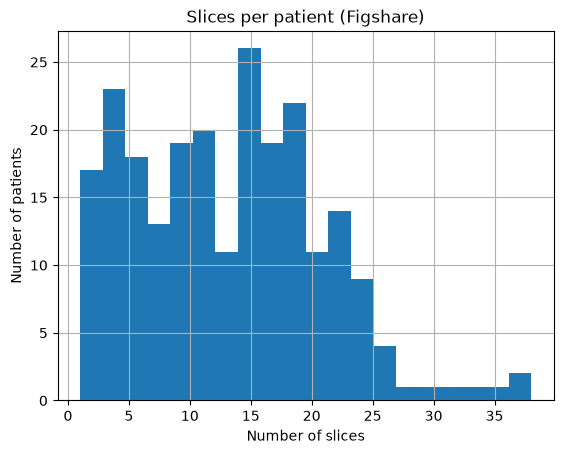

count    233.000000
mean      13.150215
std        7.655779
min        1.000000
25%        7.000000
50%       13.000000
75%       18.000000
max       38.000000
dtype: float64


In [3]:
figshare_only = metadata[metadata["source_dataset"] == "figshare"]
slices_per_patient = figshare_only.groupby("patient_id").size()

slices_per_patient.hist(bins=20)
plt.title("Slices per patient (Figshare)")
plt.xlabel("Number of slices")
plt.ylabel("Number of patients")
plt.show()

print(slices_per_patient.describe())

## Visual sample inspection

**Intent**: look at actual images per class — sanity-check labels look correct, and
visually compare Figshare vs. Br35H image style/quality/framing before we rely on both
sources together.

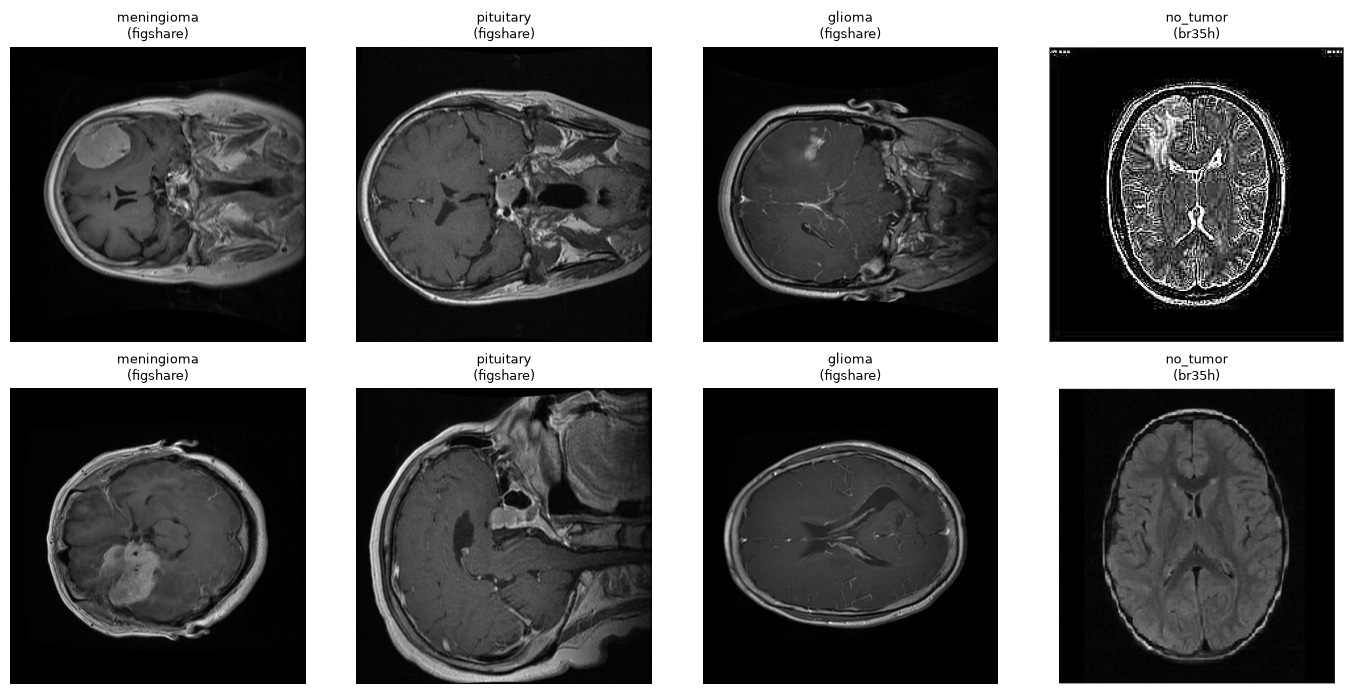

In [4]:
import h5py


def load_preview_image(row):
    if row["source_dataset"] == "figshare":
        with h5py.File(row["image_path"], "r") as f:
            return np.array(f["cjdata"]["image"])
    else:
        from PIL import Image

        return np.array(Image.open(row["image_path"]).convert("L"))


fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, label in enumerate(metadata["label"].unique()):
    sample_rows = metadata[metadata["label"] == label].sample(
        min(2, (metadata["label"] == label).sum()), random_state=1
    )
    for j, (_, row) in enumerate(sample_rows.iterrows()):
        img = load_preview_image(row)
        axes[j, i].imshow(img, cmap="gray")
        axes[j, i].set_title(f"{label}\n({row['source_dataset']})", fontsize=9)
        axes[j, i].axis("off")
plt.tight_layout()
plt.show()

## Image size / intensity consistency check (Figshare vs Br35H)

**Intent**: this is the check for the "model learns dataset source instead of tumor
presence" risk flagged in `data/README.md`. If image dimensions or intensity
distributions differ drastically by source, that's a signal to normalize more carefully
before training.

In [5]:
sample_sizes = []
sample_source = []
for _, row in metadata.sample(min(200, len(metadata)), random_state=1).iterrows():
    img = load_preview_image(row)
    sample_sizes.append(img.shape)
    sample_source.append(row["source_dataset"])

size_df = pd.DataFrame({"shape": sample_sizes, "source": sample_source})
print(size_df.groupby("source")["shape"].value_counts())

source    shape     
br35h     (225, 225)      8
          (222, 227)      4
          (417, 428)      4
          (630, 630)      4
          (168, 300)      3
          (217, 232)      3
          (244, 206)      3
          (251, 201)      3
          (197, 177)      2
          (231, 218)      2
          (234, 215)      2
          (243, 207)      2
          (183, 275)      1
          (198, 150)      1
          (213, 236)      1
          (225, 234)      1
          (242, 208)      1
          (250, 201)      1
          (257, 196)      1
          (280, 420)      1
          (326, 276)      1
          (357, 236)      1
          (361, 642)      1
          (400, 393)      1
          (442, 441)      1
          (444, 468)      1
          (530, 380)      1
          (540, 504)      1
          (680, 680)      1
figshare  (512, 512)    142
          (256, 256)      1
Name: count, dtype: int64


Next notebook: **03_patient_level_split.ipynb** — apply the leakage-safe split and
verify it with the automated leakage assertion.